In [1]:
from datetime import datetime
from arcgis.features import FeatureCollection, FeatureSet
from arcgis.gis import Item
from arcgis.geoprocessing._job import GPJob

from arcgis.gis import GIS
gis = GIS('http://deldev.maps.arcgis.com', 'demos_deldev', 'DelDevs.123', verify_cert=False)

In [2]:
from arcgis.features.summarize_data import summarize_within

In [3]:
item = gis.content.search('Traffic Collisions', 'feature layer', outside_org=True)

<Item title:"High Injury Network" type:Feature Layer Collection owner:jacqui.swartz_ladot>
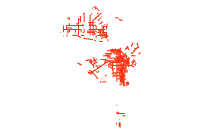

In [4]:
item[0]

In [5]:
from IPython.display import display
display(item)

[<Item title:"High Injury Network" type:Feature Layer Collection owner:jacqui.swartz_ladot>,
 <Item title:"USA Shipping Fairways Lanes Zones (Mature Support)" type:Feature Layer Collection owner:esri>,
 <Item title:"testbounding" type:Feature Layer Collection owner:demos_deldev>,
 <Item title:"Traffic_Collision_Hot_Spots_Laura_DeMars" type:Feature Layer Collection owner:ldemars1>,
 <Item title:"Five_Most_Dangerous_School_Zones_HR" type:Feature Layer Collection owner:rosenh23>,
 <Item title:"Summarize_Traffic_Collisions_within_Half_Mile_Walking_Distances_from_Schools_JB2" type:Feature Layer Collection owner:JosephBenitez1026264954>,
 <Item title:"Five_Most_Dangerous_School_Zones_RAC" type:Feature Layer Collection owner:joecasey>,
 <Item title:"Five_Most_Dangerous_School_Zones_(Raul_Mercado)" type:Feature Layer Collection owner:Raul_mercado>,
 <Item title:"Five_Most_Dangerous_School_Zones__TG" type:Feature Layer Collection owner:theagonzales16>,
 <Item title:"Mostdangerousschoolzonessimm

In [6]:
boundary = gis.content.get('d4a99c094c8b4c3f81a0fa83ea6c190c')

In [7]:
collisions = item[1]

In [8]:
county = boundary.layers[0]

In [9]:
coll_lyr = collisions.layers[0]

In [10]:
ext = coll_lyr.query(as_df=True).spatial.full_extent

In [11]:
from datetime import datetime
test = summarize_within(sum_within_layer=county,
                        summary_layer=coll_lyr,
                        sum_shape=True,
                        #group_by_field='Day',
                        minority_majority=True,
                        percent_shape=True,
                        output_name='test_summarize_within' + str(datetime.now().microsecond),
                        context={"extent":{"xmin":ext[0], "ymin":ext[1],
                                           "xmax":ext[2],"ymax":ext[3],
                                           "spatialReference":{"wkid":3857}}})

In [12]:
assert isinstance(test, Item)
test

<Item title:"test_summarize_within680612" type:Feature Layer Collection owner:demos_deldev>

In [13]:
test.delete()

True

In [14]:

print([fld['name'] for fld in county.properties.fields], county.properties.name)
print([fld['name'] for fld in coll_lyr.properties.fields], coll_lyr.properties.name)


['OBJECTID', 'GEO_ID', 'STATE', 'COUNTY', 'TRACT', 'NAME', 'LSAD', 'CENSUSAREA'] CA_CT_boundaries
['objectid', 'classification', 'description'] USA Shipping Fairways Lanes Zones


In [23]:
coll_lyr

<FeatureLayer url:"https://oceans1.arcgis.com/arcgis/rest/services/USA_Shipping_Fairways_Lanes_Zones/FeatureServer/0">

In [29]:
fc = summarize_within(sum_within_layer=county,
                        summary_layer=coll_lyr,
                        sum_shape=True,
                        group_by_field='classification',
                        minority_majority=True,
                        percent_shape=True,
                        context={"extent":{"xmin":ext[0], "ymin":ext[1],
                                           "xmax":ext[2],"ymax":ext[3],
                                           "spatialReference":{"wkid":3857}}})

In [30]:
fc

{'result_layer': <FeatureCollection>, 'group_by_summary': <FeatureCollection>}

In [31]:
assert isinstance(fc, dict)
assert isinstance(fc['result_layer'], FeatureCollection)
assert isinstance(fc['group_by_summary'], FeatureCollection)